In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import missingno as mnso
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.mixture import GaussianMixture as GMM

In [2]:
data = pd.read_csv('ML_spotify_data.csv')
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [3]:
data['artists'] = data['artists'].str.replace(r"[\[\]'\"]", "", regex=True)

In [4]:
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,Badfinger,22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,Elton John,25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,The Guess Who,21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,Joe Cocker,22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,Van Morrison,23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), str(2)
memory usage: 937.6 KB


In [6]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['popularity', 'danceability', 'valence', 'energy', 'explicit', 'key',
       'liveness', 'loudness', 'speechiness', 'tempo'],
      dtype='str')

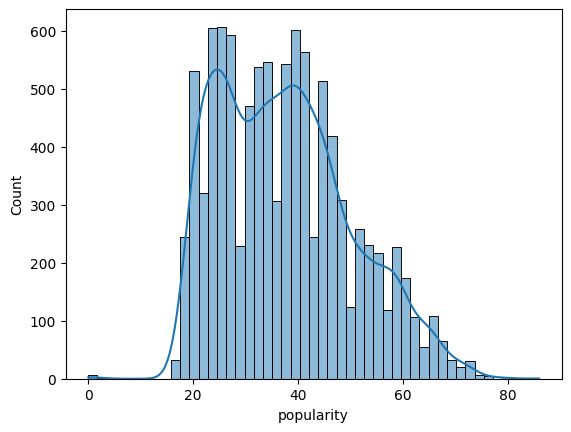

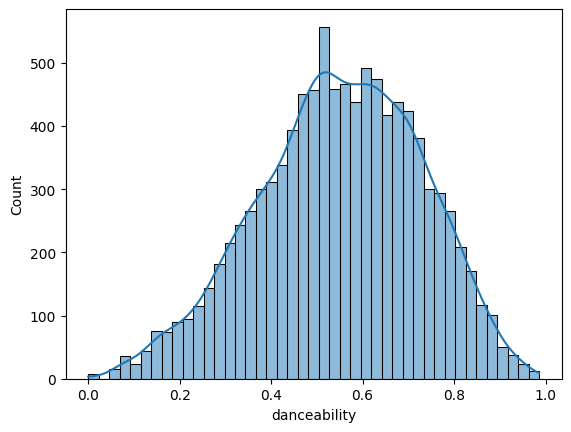

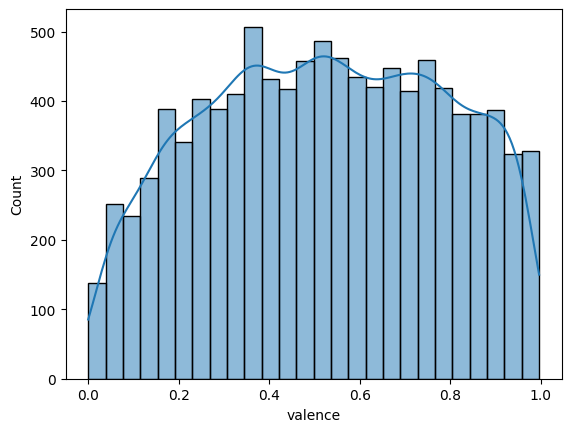

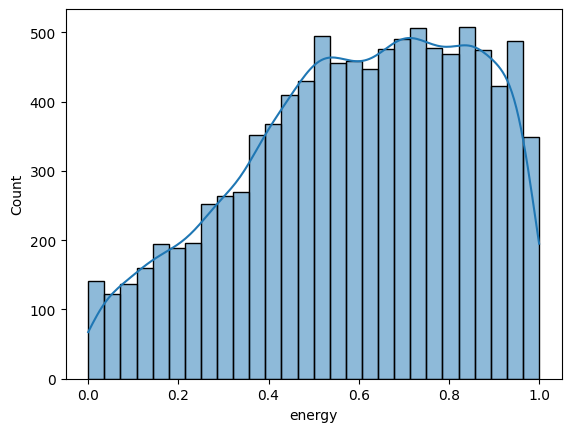

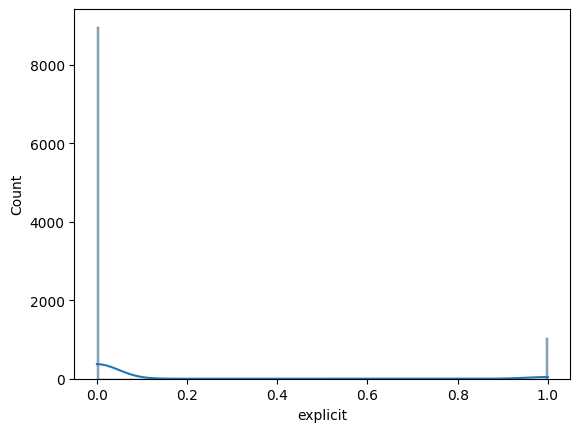

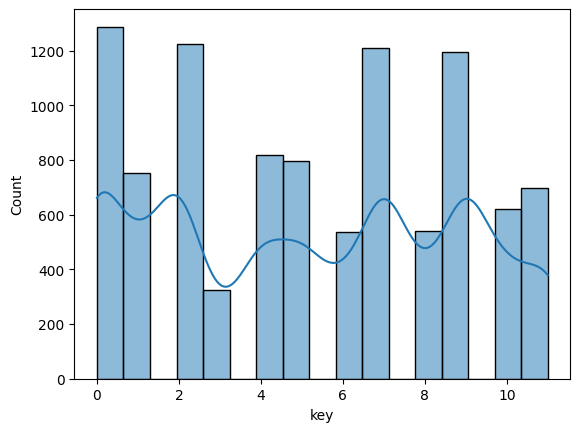

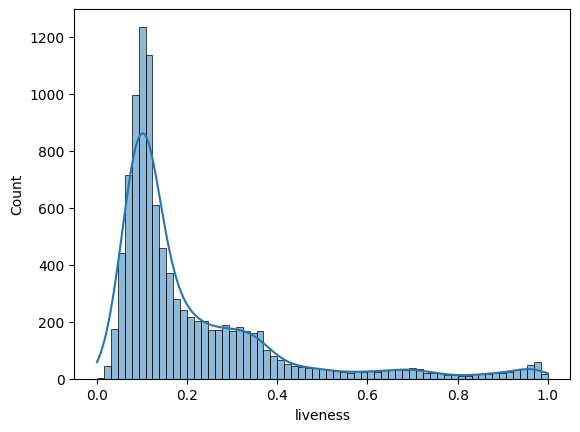

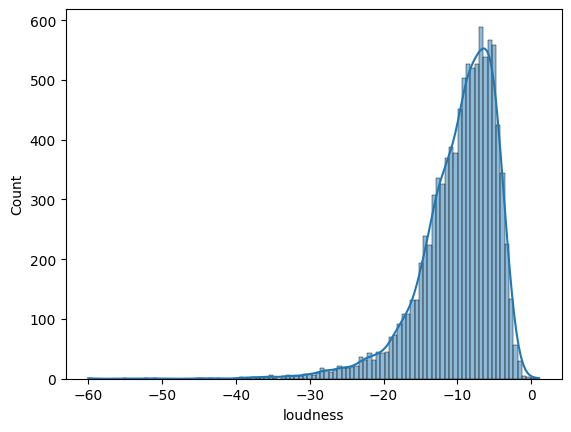

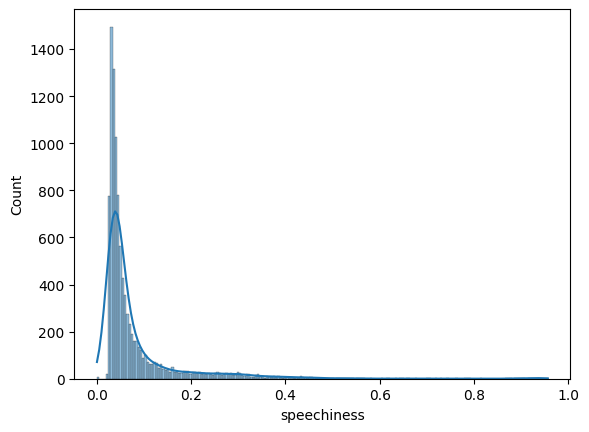

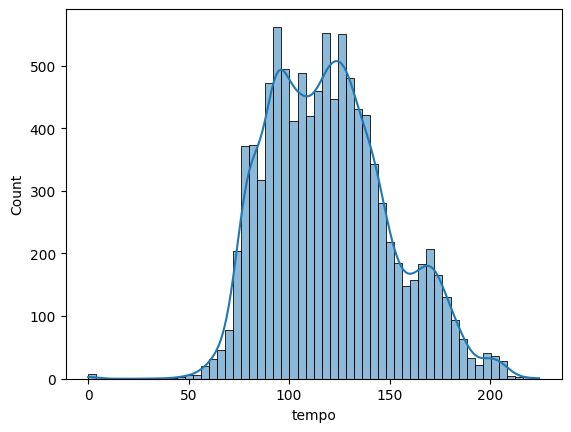

In [7]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

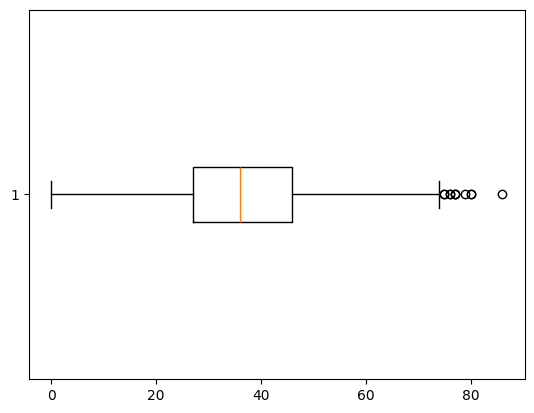

In [8]:
plt.boxplot(data['popularity'], vert = False)
plt.show()

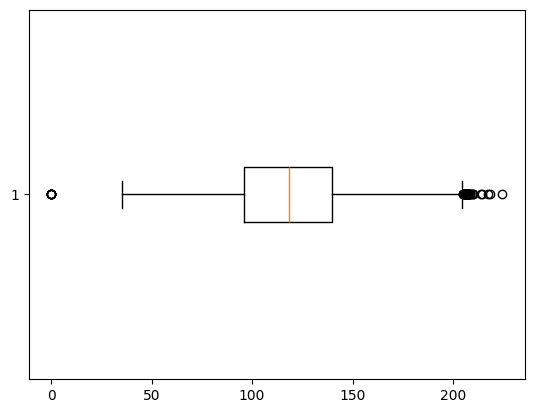

In [9]:
plt.boxplot(data['tempo'], vert = False)
plt.show()

In [10]:
Q1 = data['tempo'].quantile(0.25)
Q3 = data['tempo'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
data_2 = data[(data['tempo'] >= lower_bound)].copy()

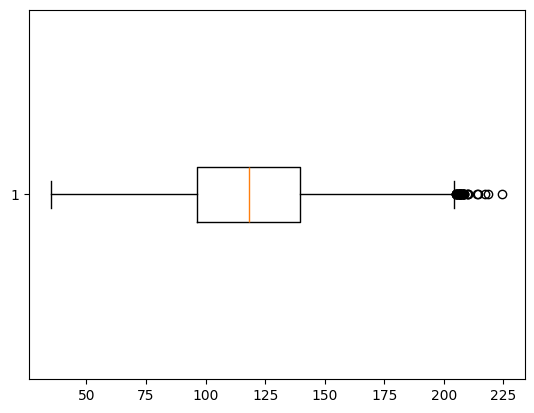

In [11]:
plt.boxplot(data_2['tempo'], vert = False)
plt.show()

In [12]:
data_2['name'].value_counts()

name
Intro                              5
Silver Bells                       5
I Believe                          4
Sleigh Ride                        4
Winter Wonderland                  4
                                  ..
China                              1
Halloweenie III: Seven Days        1
AYA                                1
Darkness                           1
Billetes Azules (with J Balvin)    1
Name: count, Length: 9703, dtype: int64

In [13]:
data_2['artists'].value_counts()

artists
U2                                                  33
Queen                                               26
Fleetwood Mac                                       25
Bob Dylan                                           25
The Rolling Stones                                  24
                                                    ..
Ólafur Arnalds                                       1
Najma Wallin                                         1
Anuel AA, Daddy Yankee, KAROL G, Ozuna, J Balvin     1
Ashnikko                                             1
KEVVO, J Balvin                                      1
Name: count, Length: 5719, dtype: int64

In [14]:
encoder = TargetEncoder(cols=['name','artists'])
data_2[['name','artists']] = encoder.fit_transform(data_2[['name','artists']], data_2['popularity'])

In [15]:
data_2.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,35.526239,35.105318,22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,35.916564,32.824670,25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,35.396130,35.044530,21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,35.526239,36.743648,22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,35.656347,34.665009,23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [16]:
X = data_2

In [17]:
standard_cols = ['popularity', 'danceability', 'valence', 'energy','key','tempo']
robust_cols = ['explicit','liveness', 'loudness', 'speechiness']

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_cols),
        ('std', StandardScaler(), standard_cols)
    ],
    remainder='passthrough' 
)
X = preprocessor.fit_transform(X)

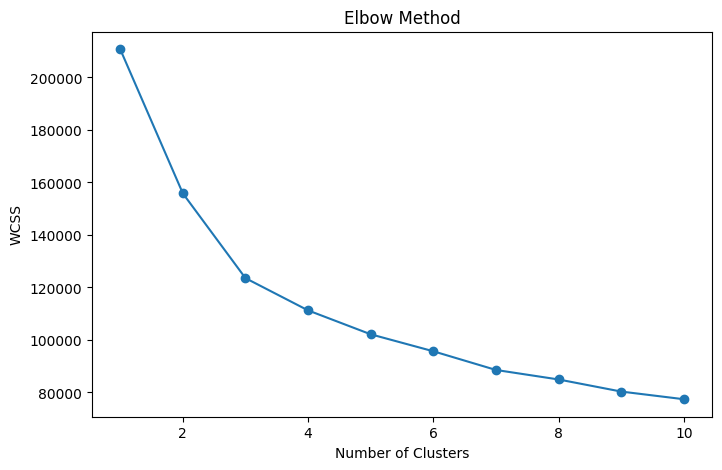

In [18]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [20]:
sc = silhouette_score(X, y_kmeans)
print("Silhouette score:", sc)

Silhouette score: 0.2617579370411501


In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [22]:
df_pca = pd.DataFrame(
    data=X_pca, columns=["PC1", "PC2"]
)
df_pca["Cluster"] = y_kmeans

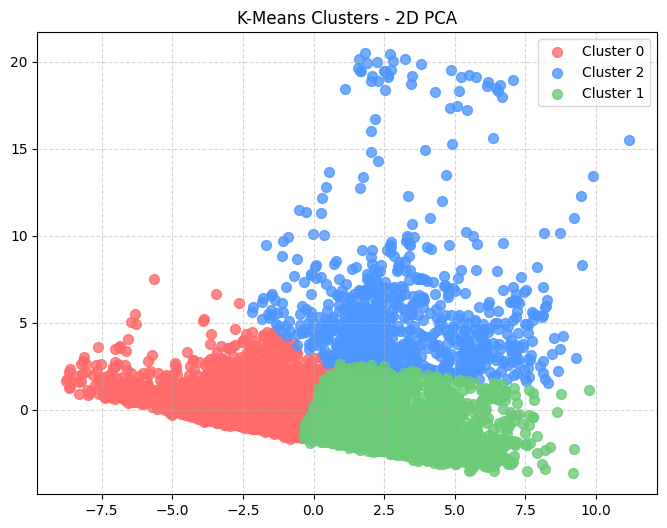

In [23]:
plt.figure(figsize=(8, 6))
targets = df_pca["Cluster"].unique()
colors = ["#FF6B6B", "#4D96FF", "#6BCB77"]

for target, color in zip(targets, colors):
    indicesToKeep = df_pca["Cluster"] == target
    plt.scatter(
        df_pca.loc[indicesToKeep, "PC1"],
        df_pca.loc[indicesToKeep, "PC2"],
        c=color,
        s=50,
        alpha=0.8,
        label=f"Cluster {target}",
    )
plt.title("K-Means Clusters - 2D PCA")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

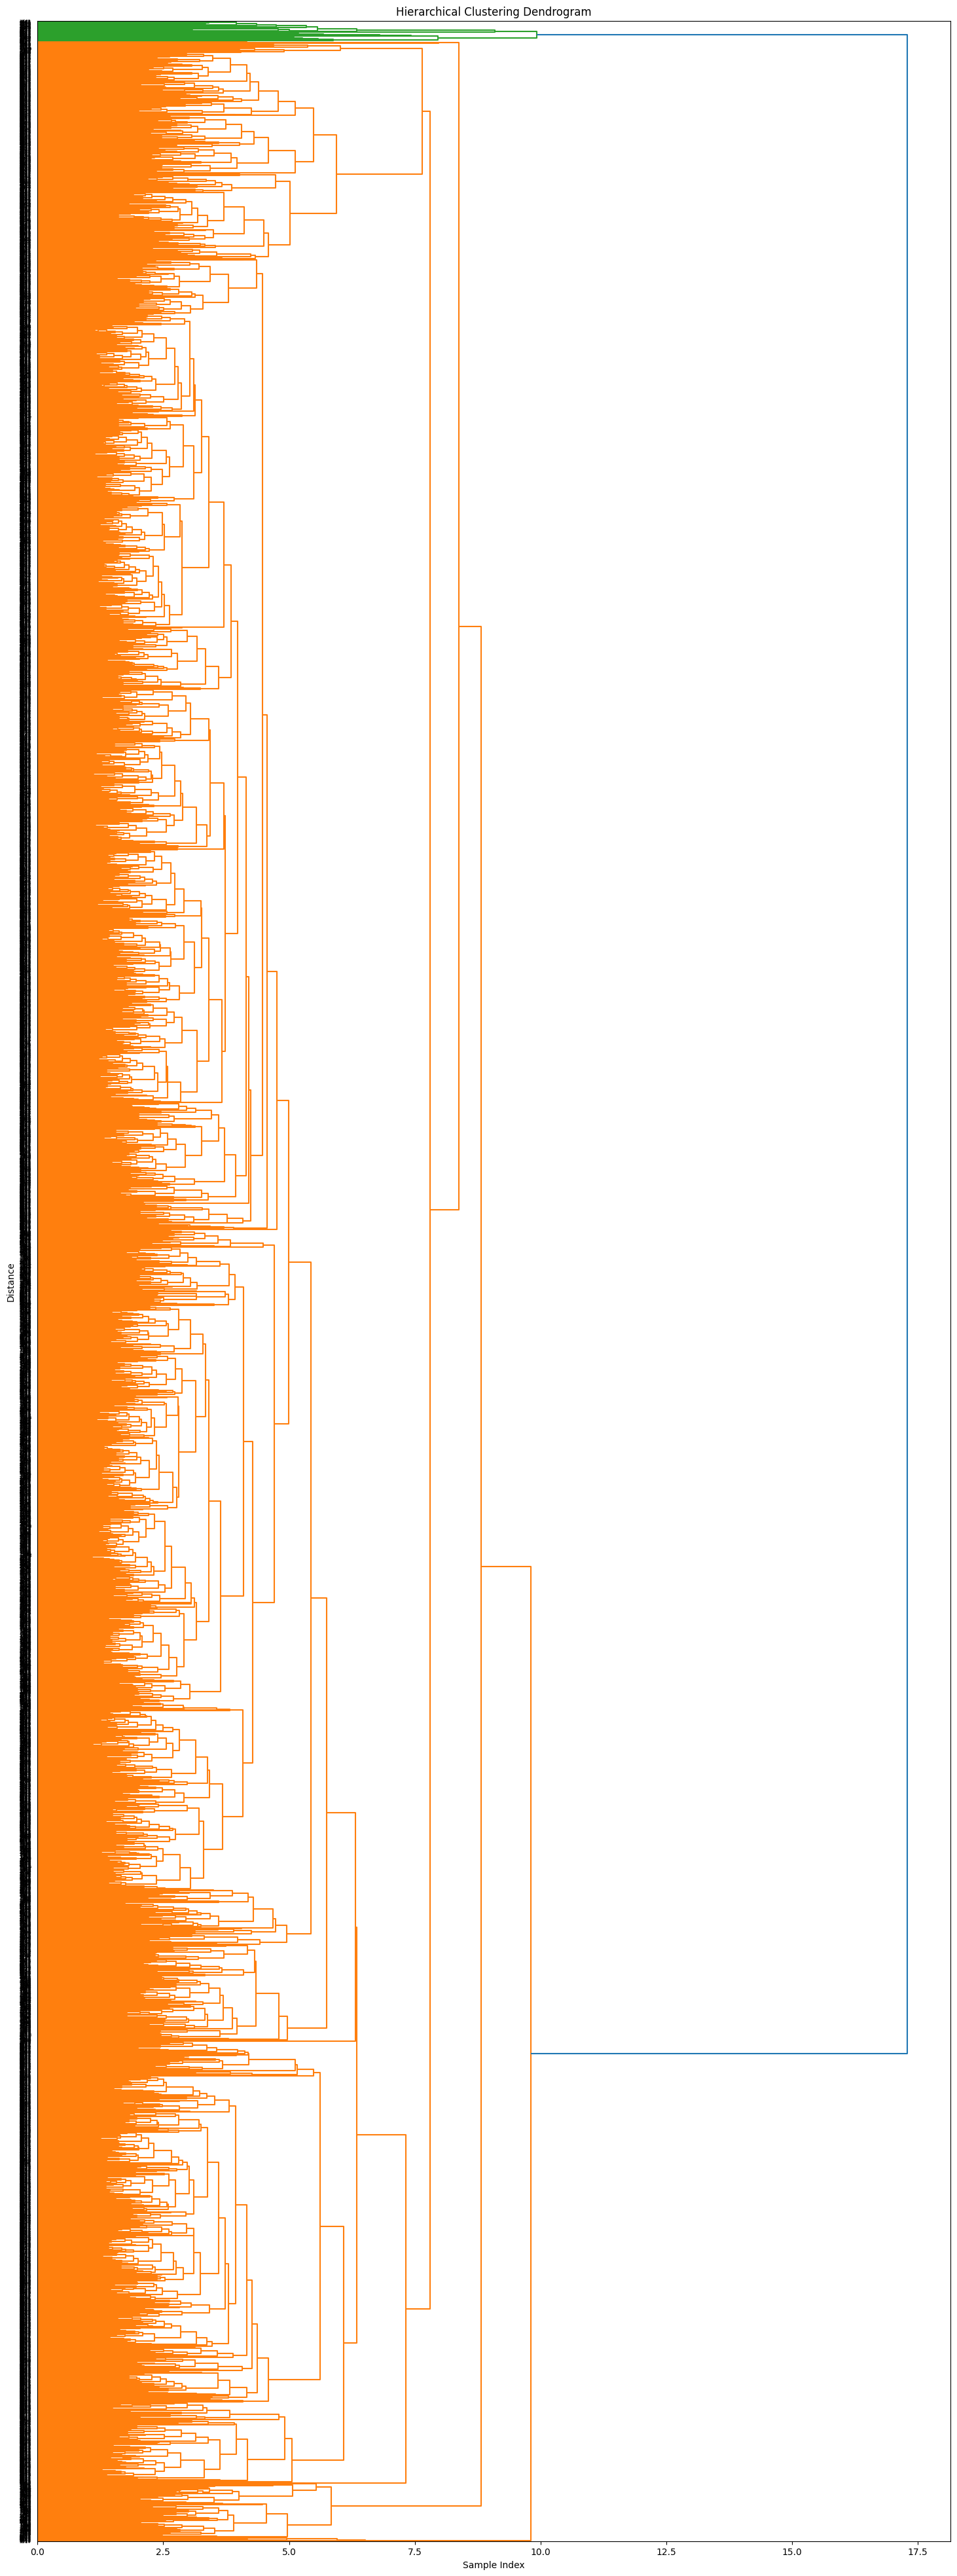

In [25]:
Z = linkage(X, method='average')

plt.figure(figsize=(18, 50))
dendrogram(Z,orientation = 'right')

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

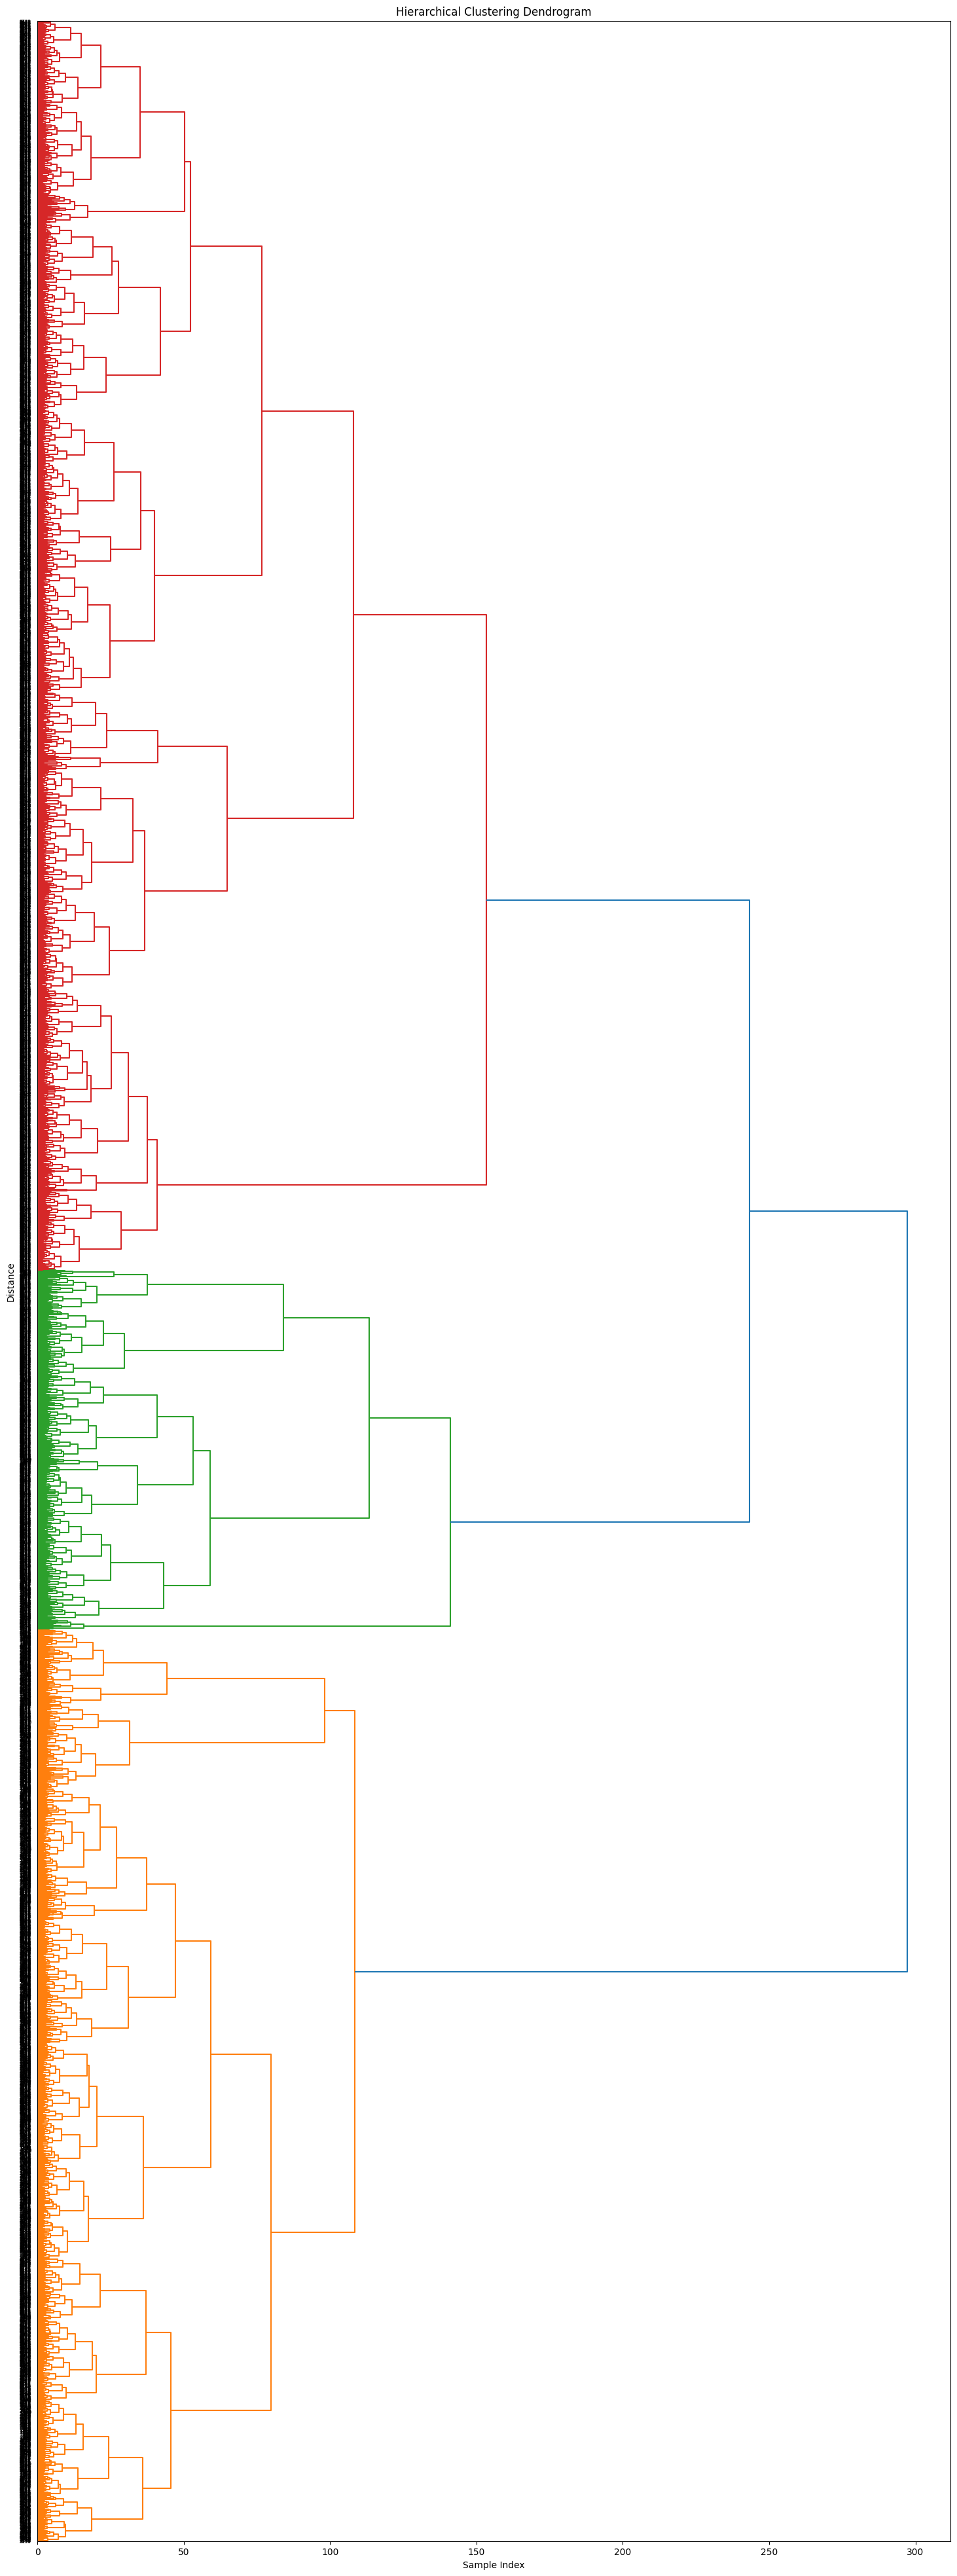

In [26]:
Z = linkage(X, method='ward')

plt.figure(figsize=(18, 50))
dendrogram(Z,orientation = 'right')

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

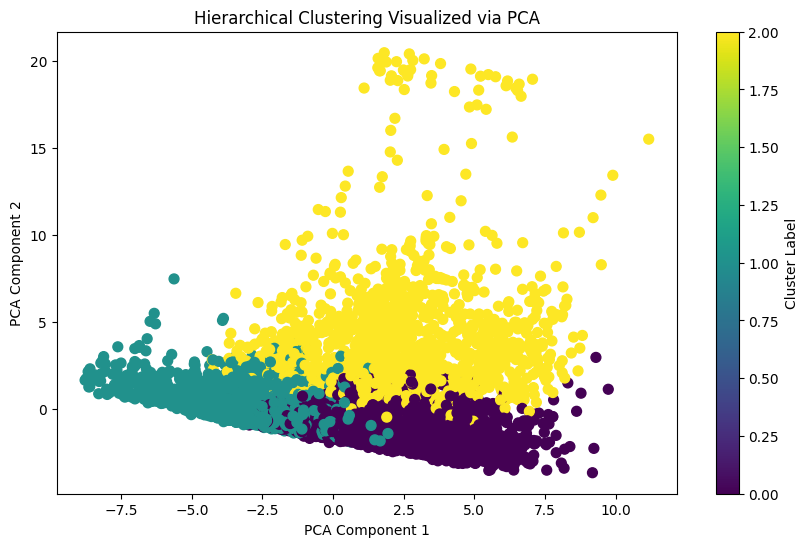

In [ ]:
cluster_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = cluster_model.fit_predict(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('Hierarchical Clustering Ward linkage via PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

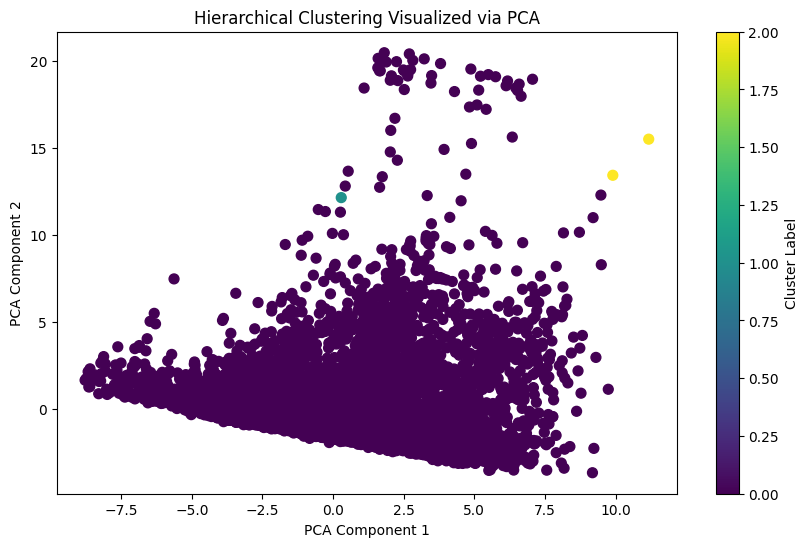

In [ ]:
cluster_model = AgglomerativeClustering(n_clusters=3, linkage='average')
cluster_labels = cluster_model.fit_predict(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('Hierarchical Clustering Single Linkage')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

In [35]:
gmm = GMM(n_components=3).fit(X)
labels = gmm.predict(X)

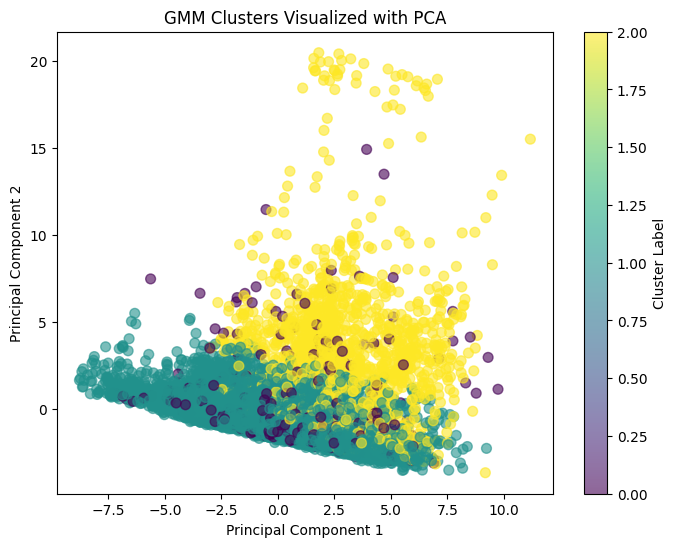

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6)
plt.colorbar(scatter, label='Cluster Label')
plt.title('GMM Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()